# Two-Stage Town Recommender: K-Means Clustering + Supervised Classification

**Objective:** Build a proper recommender that matches buyer preferences to Singapore HDB towns.

## Why Two Stages?

A single 26-class classifier struggles because many towns are nearly identical by building
features alone (e.g. Sengkang vs Punggol, Jurong East vs Jurong West). Grouping towns into
meaningful clusters first reduces noise and aligns the model with how buyers actually think —
by neighbourhood character, not individual town name.

**Stage 1 — K-Means (unsupervised):** Aggregate each town's median property characteristics
into a profile. Cluster 26 town profiles into ~5 market segments.

**Stage 2 — Supervised classifier:** Label every transaction with its town's cluster.
Train LGBM (and comparison models) to predict cluster from buyer-interpretable features.
At inference the model returns a cluster → the app returns all towns within that cluster.

---

---

## Step 1: Imports and Constants

In [1]:
import time
import json
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None
    print("LightGBM not available — skipping")

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
    print("XGBoost not available — skipping")

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None
    print("CatBoost not available — skipping")

warnings.filterwarnings('ignore')

# ── Reproducibility & hyperparameter constants ─────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.25
N_ESTIMATORS = 300

---

## Step 2: Load Dataset

In [2]:
df = pd.read_csv('../data.csv')

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Towns ({df['town'].nunique()}): {sorted(df['town'].unique())}")
df.head(2)

Shape: 270,619 rows × 76 columns
Towns (26): ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61.0,0.0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224.0,0.0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61.0,0.0,1.369092,103.839041,522.935557,Mayflower Secondary School,219.0,0.0,1.368337,103.835439


---

## Step 3: Feature Engineering

All functions reused verbatim from existing notebooks — sources noted per feature.

In [3]:
# ── distance_from_cbd (source: EDA_sprint.ipynb, Regression_Models_Comparison v2.ipynb) ──
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/lon points."""
    R = 6371.0
    phi1, phi2   = np.radians(lat1), np.radians(lat2)
    delta_phi    = np.radians(lat2 - lat1)
    delta_lam    = np.radians(lon2 - lon1)
    a = (
        np.sin(delta_phi / 2) ** 2
        + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lam / 2) ** 2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

CBD_LAT, CBD_LON = 1.2897, 103.8501  # Raffles Place
df['distance_from_cbd'] = haversine(
    df['Latitude'], df['Longitude'], CBD_LAT, CBD_LON
)

# ── storey_ratio (source: manyu_-_Classification_Models_Comparison.ipynb) ──
# mid_storey / max_floor_lvl — how high up the unit sits relative to the block
mid_storey_num = pd.to_numeric(df['mid_storey'], errors='coerce')
max_floor_safe = pd.to_numeric(df['max_floor_lvl'], errors='coerce').replace(0, np.nan)
df['storey_ratio'] = (mid_storey_num / max_floor_safe).fillna(0)

# ── is_mature_estate (source: Regression_Models_Comparison v2.ipynb) ──
# HDB's official list of mature estates (higher resale demand, more amenities)
MATURE_ESTATES = [
    'ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT MERAH', 'BUKIT TIMAH',
    'CENTRAL AREA', 'CLEMENTI', 'GEYLANG', 'KALLANG/WHAMPOA',
    'MARINE PARADE', 'PASIR RIS', 'QUEENSTOWN', 'SERANGOON',
    'TAMPINES', 'TOA PAYOH',
]
df['is_mature_estate'] = df['town'].str.upper().isin(MATURE_ESTATES).astype(int)

# ── remaining_lease (source: Regression_Models_Comparison v2.ipynb) ──
df['remaining_lease'] = 99 - df['hdb_age']

print("Feature engineering complete.")
print(f"  distance_from_cbd : {df['distance_from_cbd'].min():.1f} – {df['distance_from_cbd'].max():.1f} km")
print(f"  storey_ratio      : {df['storey_ratio'].min():.2f} – {df['storey_ratio'].max():.2f}")
print(f"  is_mature_estate  : {df['is_mature_estate'].sum():,} mature-estate transactions")

Feature engineering complete.
  distance_from_cbd : 0.7 – 19.6 km
  storey_ratio      : 0.04 – 1.50
  is_mature_estate  : 115,407 mature-estate transactions


In [4]:
# ── liveability_index (source: Nuruddin - Classification_Models_Comparison.ipynb) ──
# 5-pillar composite score [0, 1] capturing lifestyle quality of the property.
# Used for town profile clustering (Step 4) only — not a classifier input feature,
# because it cannot be accurately reconstructed from simple form inputs at inference.
#
# Pillar weights: MRT 25% | Primary School 20% | Secondary School 20% | Mall 20% | Hawker 15%

def _minmax(s):
    """Min-max normalise a Series to [0, 1]; handles NaN via median fill."""
    s = pd.to_numeric(s, errors='coerce')
    s = s.fillna(s.median())
    span = s.max() - s.min()
    return (s - s.min()) / span if span > 0 else pd.Series(0.0, index=s.index)

# MRT: proximity (70%) + interchange node bonus (30%)
mrt_prox  = _minmax(df['mrt_nearest_distance'].max() - df['mrt_nearest_distance'])
mrt_inter = pd.to_numeric(df['mrt_interchange'], errors='coerce').fillna(0).clip(0, 1)
live_mrt  = 0.7 * mrt_prox + 0.3 * mrt_inter

# Primary School: proximity (70%) + affiliation (30%)
pri_dist  = pd.to_numeric(df['pri_sch_nearest_distance'], errors='coerce').fillna(
    df['pri_sch_nearest_distance'].median()
)
pri_prox  = _minmax(pri_dist.max() - pri_dist)
pri_aff   = _minmax(pd.to_numeric(df['pri_sch_affiliation'], errors='coerce').fillna(0))
live_pri  = 0.7 * pri_prox + 0.3 * pri_aff

# Secondary School: proximity only
sec_dist  = pd.to_numeric(df['sec_sch_nearest_dist'], errors='coerce').fillna(
    df['sec_sch_nearest_dist'].median()
)
live_sec  = _minmax(sec_dist.max() - sec_dist)

# Hawker: proximity (60%) + food stall count (40%)
hawk_prox  = _minmax(df['Hawker_Nearest_Distance'].max() - df['Hawker_Nearest_Distance'])
hawk_stall = _minmax(pd.to_numeric(df['hawker_food_stalls'], errors='coerce').fillna(0))
live_hawk  = 0.6 * hawk_prox + 0.4 * hawk_stall

# Mall: proximity (50%) + count within 2km (50%)
mall_prox = _minmax(df['Mall_Nearest_Distance'].max() - df['Mall_Nearest_Distance'])
mall_cnt  = _minmax(pd.to_numeric(df['Mall_Within_2km'], errors='coerce').fillna(0))
live_mall = 0.5 * mall_prox + 0.5 * mall_cnt

df['liveability_index'] = (
    0.25 * live_mrt
    + 0.20 * live_pri
    + 0.20 * live_sec
    + 0.20 * live_mall
    + 0.15 * live_hawk
)

print(f"liveability_index range: {df['liveability_index'].min():.3f} – {df['liveability_index'].max():.3f}")

liveability_index range: 0.111 – 0.811


---

## Step 4: Build Town Profiles

Aggregate the dataset to **one row per town** (26 rows). Each row is the median of key
property characteristics — this is the input to K-Means clustering.
Normalise with MinMaxScaler because K-Means is distance-based and scale matters.

In [5]:
# Features used to characterise each town
PROFILE_FEATURES = [
    'resale_price',             # affordability
    'floor_area_sqm',           # typical flat size
    'hdb_age',                  # estate maturity
    'distance_from_cbd',        # location relative to city centre
    'mrt_nearest_distance',     # transit accessibility
    'Hawker_Nearest_Distance',  # hawker convenience
    'Mall_Nearest_Distance',    # retail convenience
    'pri_sch_nearest_distance', # school access
    'max_floor_lvl',            # building height character
    'liveability_index',        # composite lifestyle score
]

# Aggregate: one row per town, median of each feature
town_profiles = df.groupby('town')[PROFILE_FEATURES].median().reset_index()

# Normalise for K-Means (distance-based — scale matters)
profile_scaler  = MinMaxScaler()
profiles_scaled = profile_scaler.fit_transform(town_profiles[PROFILE_FEATURES])

print(f"Town profiles: {town_profiles.shape[0]} towns x {len(PROFILE_FEATURES)} features")
town_profiles[['town'] + PROFILE_FEATURES].round(1)

Town profiles: 26 towns x 10 features


,town,resale_price,floor_area_sqm,hdb_age,distance_from_cbd,mrt_nearest_distance,Hawker_Nearest_Distance,Mall_Nearest_Distance,pri_sch_nearest_distance,max_floor_lvl,liveability_index
0,ANG MO KIO,400000.0,81.0,45.0,9.0,685.0,314.4,805.0,410.8,12.0,0.6
1,BEDOK,416000.0,85.0,45.0,9.9,621.4,365.8,891.9,430.3,13.0,0.6
2,BISHAN,655000.0,105.0,37.0,7.3,750.2,806.2,809.0,416.1,13.0,0.7
3,BUKIT BATOK,440000.0,93.0,38.0,13.4,678.3,1899.8,914.4,384.3,13.0,0.6
4,BUKIT MERAH,620000.0,90.0,40.0,3.2,567.9,287.2,700.2,391.1,21.0,0.6
5,BUKIT PANJANG,465000.0,103.0,26.0,14.0,607.6,1036.1,445.7,335.1,17.0,0.7
6,BUKIT TIMAH,735000.0,104.0,37.0,10.0,363.8,292.0,546.1,382.4,13.0,0.6
7,CENTRAL AREA,533000.0,82.0,42.0,1.7,338.3,196.1,296.3,435.2,21.0,0.7
8,CHOA CHU KANG,470000.0,106.0,27.0,15.8,611.6,3410.3,357.8,357.2,15.0,0.6
9,CLEMENTI,452000.0,82.0,45.0,9.8,674.9,405.2,497.5,487.4,12.0,0.6


---

## Step 5: K-Means Clustering

Find the optimal number of clusters using the **elbow method** (inertia) and
**silhouette score**. Then fit the final model, visualise with PCA, and assign
each cluster a descriptive name.

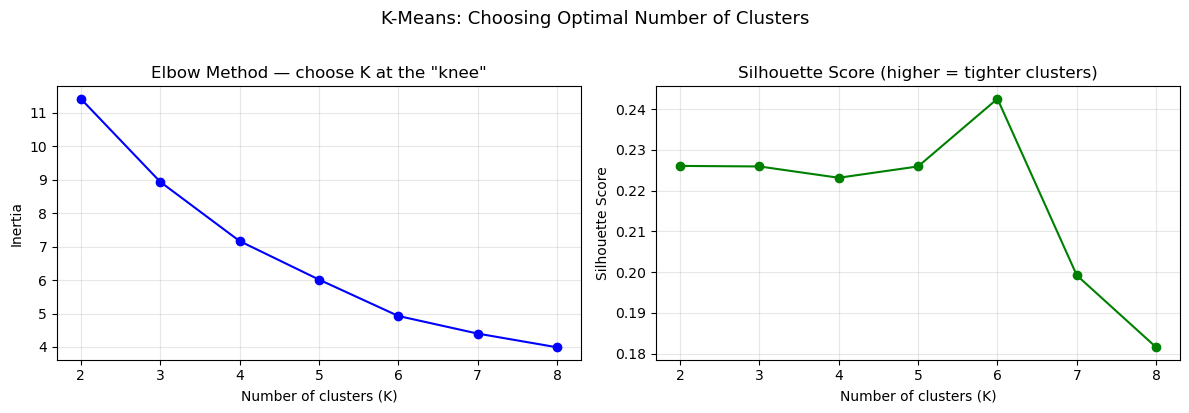


K  | Inertia     | Silhouette
-----------------------------------
2  |     11.417  | 0.2261
3  |      8.935  | 0.2259
4  |      7.165  | 0.2232
5  |      6.014  | 0.2259
6  |      4.926  | 0.2426
7  |      4.400  | 0.1992
8  |      3.990  | 0.1815


In [6]:
# ── Elbow + Silhouette analysis ────────────────────────────────────────────
K_RANGE     = range(2, 9)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(profiles_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(profiles_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_RANGE), inertias, 'bo-', markersize=6)
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method — choose K at the "knee"')
ax1.grid(alpha=0.3)

ax2.plot(list(K_RANGE), silhouettes, 'go-', markersize=6)
ax2.set_xlabel('Number of clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (higher = tighter clusters)')
ax2.grid(alpha=0.3)

plt.suptitle('K-Means: Choosing Optimal Number of Clusters', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nK  | Inertia     | Silhouette")
print("-" * 35)
for k, iner, sil in zip(K_RANGE, inertias, silhouettes):
    print(f"{k}  | {iner:10.3f}  | {sil:.4f}")

In [7]:
# ── Fit final K-Means ──────────────────────────────────────────────────────
# Set OPTIMAL_K based on the elbow + silhouette plots above.
# Expected: 5 (aligns roughly with Singapore's 5 planning regions)
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
town_profiles['cluster'] = kmeans.fit_predict(profiles_scaled)

# Print cluster membership with key stats to help interpret each group
print(f"K = {OPTIMAL_K} — Town cluster assignments:\n")
for cid in sorted(town_profiles['cluster'].unique()):
    mask   = town_profiles['cluster'] == cid
    towns  = town_profiles.loc[mask, 'town'].tolist()
    stats  = town_profiles.loc[mask, PROFILE_FEATURES].median()
    print(f"  Cluster {cid} ({len(towns)} towns): {', '.join(towns)}")
    print(f"    Median price: ${stats['resale_price']:,.0f}  |  "
          f"CBD dist: {stats['distance_from_cbd']:.1f} km  |  "
          f"HDB age: {stats['hdb_age']:.0f} yrs  |  "
          f"Liveability: {stats['liveability_index']:.3f}")
    print()

K = 5 — Town cluster assignments:

  Cluster 0 (3 towns): BUKIT MERAH, CENTRAL AREA, QUEENSTOWN
    Median price: $605,000  |  CBD dist: 3.2 km  |  HDB age: 40 yrs  |  Liveability: 0.644

  Cluster 1 (5 towns): BUKIT PANJANG, CHOA CHU KANG, PUNGGOL, SEMBAWANG, SENGKANG
    Median price: $475,000  |  CBD dist: 14.0 km  |  HDB age: 24 yrs  |  Liveability: 0.662

  Cluster 2 (9 towns): BISHAN, BUKIT TIMAH, HOUGANG, JURONG WEST, PASIR RIS, SERANGOON, TAMPINES, WOODLANDS, YISHUN
    Median price: $500,888  |  CBD dist: 12.9 km  |  HDB age: 37 yrs  |  Liveability: 0.644

  Cluster 3 (8 towns): ANG MO KIO, BEDOK, BUKIT BATOK, CLEMENTI, GEYLANG, JURONG EAST, KALLANG/WHAMPOA, TOA PAYOH
    Median price: $435,000  |  CBD dist: 9.4 km  |  HDB age: 42 yrs  |  Liveability: 0.632

  Cluster 4 (1 towns): MARINE PARADE
    Median price: $490,000  |  CBD dist: 7.2 km  |  HDB age: 50 yrs  |  Liveability: 0.567



In [8]:
# ── Name the clusters ──────────────────────────────────────────────────────
# Based on actual cluster output from Step 5:
#   0: Bukit Merah, Central Area, Queenstown          — high price, 3.2km CBD, mature
#   1: Bukit Panjang, CCK, Punggol, Sembawang, Sengkang — newer towns, 14km CBD
#   2: Bishan, Bukit Timah, Hougang, Jurong West,
#      Pasir Ris, Serangoon, Tampines, Woodlands, Yishun — mixed outer estates
#   3: AMK, Bedok, Bukit Batok, Clementi, Geylang,
#      Jurong East, Kallang/Whampoa, Toa Payoh          — affordable mature, 9.4km CBD
#   4: Marine Parade                                   — oldest estate (50yr), coastal
CLUSTER_NAMES = {
    0: "City Fringe Premium",
    1: "New Suburban Towns",
    2: "Established Outer Estates",
    3: "Affordable Mature Estates",
    4: "East Coast Heritage",
}

town_profiles['cluster_name'] = town_profiles['cluster'].map(CLUSTER_NAMES)

print("Cluster → Town mapping:")
print(town_profiles[['town', 'cluster', 'cluster_name']]
      .sort_values('cluster')
      .to_string(index=False))

Cluster → Town mapping:
           town  cluster              cluster_name
   CENTRAL AREA        0       City Fringe Premium
    BUKIT MERAH        0       City Fringe Premium
     QUEENSTOWN        0       City Fringe Premium
  BUKIT PANJANG        1        New Suburban Towns
       SENGKANG        1        New Suburban Towns
      SEMBAWANG        1        New Suburban Towns
        PUNGGOL        1        New Suburban Towns
  CHOA CHU KANG        1        New Suburban Towns
      WOODLANDS        2 Established Outer Estates
       TAMPINES        2 Established Outer Estates
      SERANGOON        2 Established Outer Estates
      PASIR RIS        2 Established Outer Estates
    BUKIT TIMAH        2 Established Outer Estates
    JURONG WEST        2 Established Outer Estates
        HOUGANG        2 Established Outer Estates
         BISHAN        2 Established Outer Estates
         YISHUN        2 Established Outer Estates
KALLANG/WHAMPOA        3 Affordable Mature Estates
    JUR

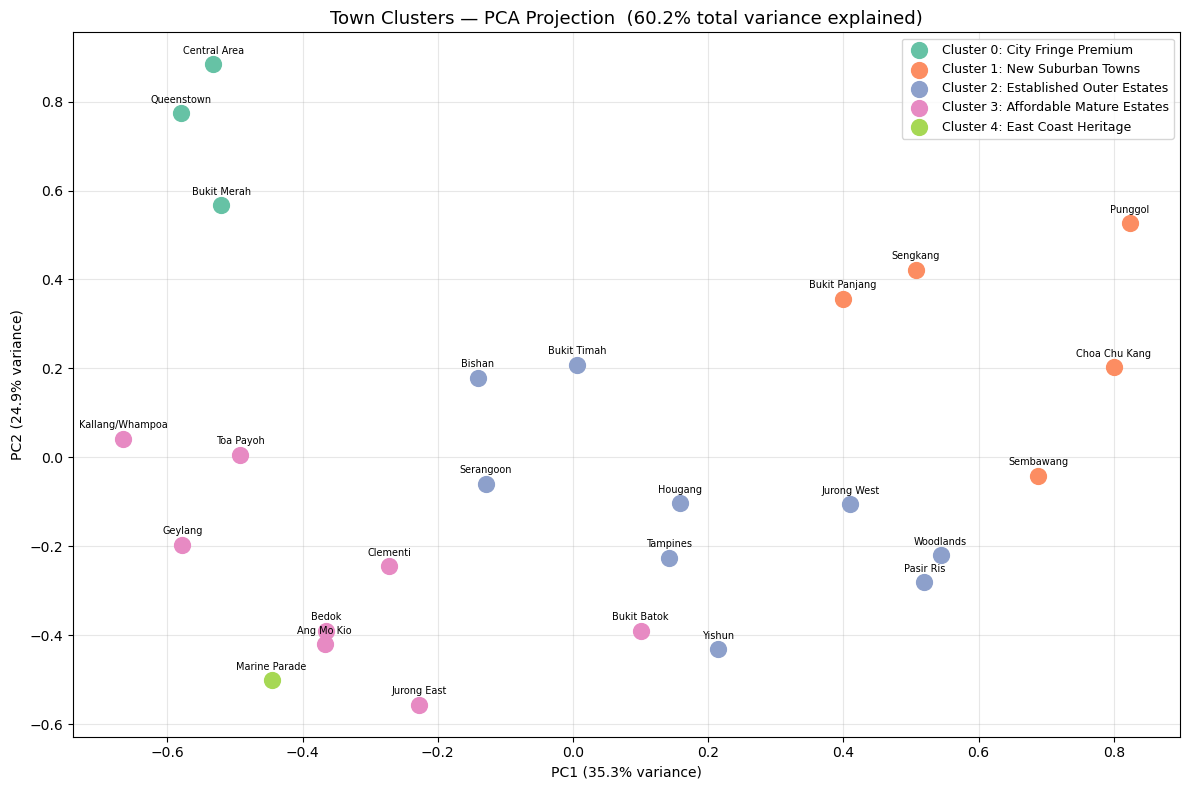

In [9]:
# ── PCA visualisation (2D projection of 10-feature space) ─────────────────
pca        = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(profiles_scaled)
palette    = sns.color_palette('Set2', OPTIMAL_K)

fig, ax = plt.subplots(figsize=(12, 8))

for cid in sorted(town_profiles['cluster'].unique()):
    mask = town_profiles['cluster'] == cid
    ax.scatter(
        pca_coords[mask, 0], pca_coords[mask, 1],
        color=palette[cid], s=130, zorder=2,
        label=f"Cluster {cid}: {CLUSTER_NAMES[cid]}"
    )

# Label each dot with the town name
for i, row in town_profiles.iterrows():
    ax.annotate(
        row['town'].title(),
        (pca_coords[i, 0], pca_coords[i, 1]),
        fontsize=7, ha='center', va='bottom',
        xytext=(0, 6), textcoords='offset points'
    )

var_explained = sum(pca.explained_variance_ratio_[:2]) * 100
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title(
    f"Town Clusters — PCA Projection  "
    f"({var_explained:.1f}% total variance explained)",
    fontsize=13
)
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# ── Propagate cluster labels to every transaction in df ───────────────────
town_to_cluster      = dict(zip(town_profiles['town'], town_profiles['cluster']))
df['cluster_label']  = df['town'].map(town_to_cluster)

print("Cluster distribution in full dataset:")
cluster_counts = df['cluster_label'].value_counts().sort_index()
for cid, cnt in cluster_counts.items():
    name = CLUSTER_NAMES[cid]
    print(f"  Cluster {cid} ({name}): {cnt:,} transactions ({cnt/len(df)*100:.1f}%)")

Cluster distribution in full dataset:
  Cluster 0 (City Fringe Premium): 19,847 transactions (7.3%)
  Cluster 1 (New Suburban Towns): 67,412 transactions (24.9%)
  Cluster 2 (Established Outer Estates): 108,073 transactions (39.9%)
  Cluster 3 (Affordable Mature Estates): 73,570 transactions (27.2%)
  Cluster 4 (East Coast Heritage): 1,717 transactions (0.6%)


---

## Step 6: Feature Selection for Supervised Classifier

Features must be:
1. **Interpretable** — the buyer can state a preference in these terms
2. **Reconstructible at inference** — the app can derive the value from form inputs

`distance_from_cbd` replaces `age_location_score` as the location signal — it is direct
and unambiguous (no interaction term masking the effect).

`pri_sch_nearest_distance` is included as the 10th feature — school access is a
meaningful differentiator between clusters (central/mature areas have denser school
coverage) and maps cleanly to a "Near School" toggle at inference.

`liveability_index` is excluded from the classifier (used only in town profiles): it is a
complex composite that cannot be accurately reconstructed from form checkboxes.

In [11]:
# 10 buyer-interpretable features — each maps directly to a form input in the web app
CLASSIFIER_FEATURES = [
    'resale_price',               # budget
    'floor_area_sqm',             # flat size
    'hdb_age',                    # estate age preference
    'distance_from_cbd',          # location (form: region pill → km value)
    'mrt_nearest_distance',       # MRT access (form: Near MRT toggle → 500m or 1500m)
    'Hawker_Nearest_Distance',    # hawker access (form: Near Hawker toggle → 300m or 1000m)
    'Mall_Nearest_Distance',      # mall access (form: Near Mall toggle → 500m or 1500m)
    'pri_sch_nearest_distance',   # school access (form: Near School toggle → 500m or 1500m)
    'max_floor_lvl',              # building height preference
    'storey_ratio',               # floor preference
]
TARGET = 'cluster_label'

X = df[CLASSIFIER_FEATURES].copy()
y = df[TARGET].copy()

# Drop rows with nulls in any feature or target
valid_mask = X.notna().all(axis=1) & y.notna()
X, y = X[valid_mask], y[valid_mask]

print(f"Dataset: {X.shape[0]:,} transactions x {X.shape[1]} features")
print(f"Target classes: {sorted(y.unique())} ({y.nunique()} clusters)")
print()
X.describe().round(2)

Dataset: 265,409 transactions x 10 features
Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] (5 clusters)



,resale_price,floor_area_sqm,hdb_age,distance_from_cbd,mrt_nearest_distance,Hawker_Nearest_Distance,Mall_Nearest_Distance,pri_sch_nearest_distance,max_floor_lvl,storey_ratio
count,265409.00,265409.00,265409.00,265409.00,265409.00,265409.00,265409.00,265409.00,265409.00,265409.00
mean,505340.59,96.78,30.57,11.97,701.52,1162.51,662.99,409.60,15.52,0.56
std,175092.98,24.29,13.53,4.36,415.26,1067.46,365.32,246.34,6.50,0.28
min,150000.00,31.00,3.00,0.69,21.97,1.87,0.00,42.55,2.00,0.04
25%,377400.00,75.00,22.00,9.16,399.40,377.83,392.78,232.04,12.00,0.33
50%,470000.00,93.00,32.00,12.89,628.18,780.74,602.13,360.24,14.00,0.53
75%,600000.00,112.00,41.00,15.08,906.70,1636.07,870.01,523.93,17.00,0.80
max,1658888.00,366.70,59.00,19.58,3544.50,4816.06,3496.40,3306.00,50.00,1.50


---

## Step 7: Train / Test Split, SMOTE, and Scaling

In [12]:
# Stratified split preserves cluster proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

# SMOTE on training set only — balances cluster class sizes without touching test data
sm = SMOTE(random_state=RANDOM_STATE)
X_train, y_train = sm.fit_resample(X_train, y_train)
print(f"After SMOTE — Train: {X_train.shape[0]:,}")

unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution after SMOTE:", dict(zip(unique.tolist(), counts.tolist())))

# StandardScaler fitted on training data only (prevents data leakage to test set)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

Train: 199,056  |  Test: 66,353


After SMOTE — Train: 401,930
Class distribution after SMOTE: {0: 80386, 1: 80386, 2: 80386, 3: 80386, 4: 80386}


---

## Step 8: Train and Compare Models

All models trained on the same scaled data. Results compared on:
- **Test Accuracy** — primary metric
- **Generalization Gap** — Train Acc − Test Acc (lower = less overfitting)
- **Runtime** — training time in seconds

Selection rule: within 0.01 of best test accuracy, pick the model with lowest runtime
(same rule used in `manyu_-_Classification_Models_Comparison.ipynb`).

In [13]:
# ── Evaluation helper (reused from manyu_-_Classification_Models_Comparison.ipynb) ──
def evaluate_classification_model(
    model, X_train_data, X_test_data,
    y_train_data, y_test_data,
    model_name, feature_columns
):
    """Fit model, compute accuracy metrics, extract feature importances."""
    start  = time.perf_counter()
    model.fit(X_train_data, y_train_data)
    runtime = time.perf_counter() - start

    train_pred = model.predict(X_train_data)
    test_pred  = model.predict(X_test_data)

    # CatBoost returns object arrays — coerce to int
    if 'CatBoost' in type(model).__name__:
        train_pred = np.array(train_pred).astype(int).ravel()
        test_pred  = np.array(test_pred).astype(int).ravel()

    train_acc = accuracy_score(y_train_data, train_pred)
    test_acc  = accuracy_score(y_test_data,  test_pred)

    # Feature importances for tree-based; mean absolute coefficients for linear
    if hasattr(model, 'feature_importances_'):
        imp_vals = model.feature_importances_
    elif hasattr(model, 'coef_'):
        coef     = model.coef_
        imp_vals = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
    else:
        imp_vals = np.zeros(len(feature_columns))

    importance_df = pd.DataFrame({
        'Feature':    feature_columns,
        'Importance': imp_vals,
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    return {
        'Model':               model_name,
        'Train Accuracy':      train_acc,
        'Test Accuracy':       test_acc,
        'Generalization Gap':  train_acc - test_acc,
        'Runtime (sec)':       runtime,
        'Feature Importance':  importance_df,
        'fitted_model':        model,
    }

In [14]:
# ── Train all models ───────────────────────────────────────────────────────
results = []

# Logistic Regression — linear baseline
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
results.append(evaluate_classification_model(
    lr_model, X_train_sc, X_test_sc, y_train, y_test,
    'Logistic Regression', CLASSIFIER_FEATURES
))
print(f"Logistic Regression done  — Test Acc: {results[-1]['Test Accuracy']:.4f}")

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1
)
results.append(evaluate_classification_model(
    rf_model, X_train_sc, X_test_sc, y_train, y_test,
    'Random Forest', CLASSIFIER_FEATURES
))
print(f"Random Forest done        — Test Acc: {results[-1]['Test Accuracy']:.4f}")

# LightGBM
if LGBMClassifier is not None:
    lgbm_model = LGBMClassifier(
        n_estimators=N_ESTIMATORS, learning_rate=0.05,
        num_leaves=31, random_state=RANDOM_STATE, verbosity=-1
    )
    results.append(evaluate_classification_model(
        lgbm_model, X_train_sc, X_test_sc, y_train, y_test,
        'LightGBM', CLASSIFIER_FEATURES
    ))
    print(f"LightGBM done             — Test Acc: {results[-1]['Test Accuracy']:.4f}")

# XGBoost
if XGBClassifier is not None:
    xgb_model = XGBClassifier(
        n_estimators=N_ESTIMATORS, learning_rate=0.05,
        random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0
    )
    results.append(evaluate_classification_model(
        xgb_model, X_train_sc, X_test_sc, y_train, y_test,
        'XGBoost', CLASSIFIER_FEATURES
    ))
    print(f"XGBoost done              — Test Acc: {results[-1]['Test Accuracy']:.4f}")

# CatBoost
if CatBoostClassifier is not None:
    cb_model = CatBoostClassifier(
        iterations=N_ESTIMATORS, learning_rate=0.05,
        random_state=RANDOM_STATE, verbose=0
    )
    results.append(evaluate_classification_model(
        cb_model, X_train_sc, X_test_sc, y_train, y_test,
        'CatBoost', CLASSIFIER_FEATURES
    ))
    print(f"CatBoost done             — Test Acc: {results[-1]['Test Accuracy']:.4f}")

print(f"\n{len(results)} models trained.")

Logistic Regression done  — Test Acc: 0.7677


Random Forest done        — Test Acc: 0.9999


LightGBM done             — Test Acc: 0.9998


XGBoost done              — Test Acc: 0.9956


CatBoost done             — Test Acc: 0.9736

5 models trained.


In [15]:
# ── Comparison table + model selection ────────────────────────────────────
comparison_df = pd.DataFrame([{
    'Model':              r['Model'],
    'Train Accuracy':     round(r['Train Accuracy'],     4),
    'Test Accuracy':      round(r['Test Accuracy'],      4),
    'Generalization Gap': round(r['Generalization Gap'], 4),
    'Runtime (sec)':      round(r['Runtime (sec)'],      2),
} for r in results]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

display(comparison_df)

# Select recommended model: within 0.01 of best, pick fastest
ACCURACY_TOLERANCE = 0.01
best_test   = comparison_df['Test Accuracy'].max()
candidates  = comparison_df[
    comparison_df['Test Accuracy'] >= best_test - ACCURACY_TOLERANCE
].sort_values(['Runtime (sec)', 'Generalization Gap']).reset_index(drop=True)

recommended_name   = candidates.iloc[0]['Model']
recommended_row    = candidates.iloc[0]
recommended_result = next(r for r in results if r['Model'] == recommended_name)

print(f"\n★ Recommended model: {recommended_name}")
print(f"  Test accuracy:      {recommended_row['Test Accuracy']:.4f} "
      f"({recommended_row['Test Accuracy']*100:.2f}%)")
print(f"  Generalization gap: {recommended_row['Generalization Gap']:.4f}")
print(f"  Runtime:            {recommended_row['Runtime (sec)']:.2f}s")

,Model,Train Accuracy,Test Accuracy,Generalization Gap,Runtime (sec)
0,Random Forest,1.0000,0.9999,0.0001,64.37
1,LightGBM,0.9983,0.9998,-0.0015,16.77
2,XGBoost,0.9931,0.9956,-0.0025,20.63
3,CatBoost,0.9776,0.9736,0.0040,32.80
4,Logistic Regression,0.8387,0.7677,0.0710,9.11



★ Recommended model: LightGBM
  Test accuracy:      0.9998 (99.98%)
  Generalization gap: -0.0015
  Runtime:            16.77s


---

## Step 9: Feature Importance

Which features most strongly determine cluster membership? These are the dimensions
buyers should consider most carefully when choosing a town type.

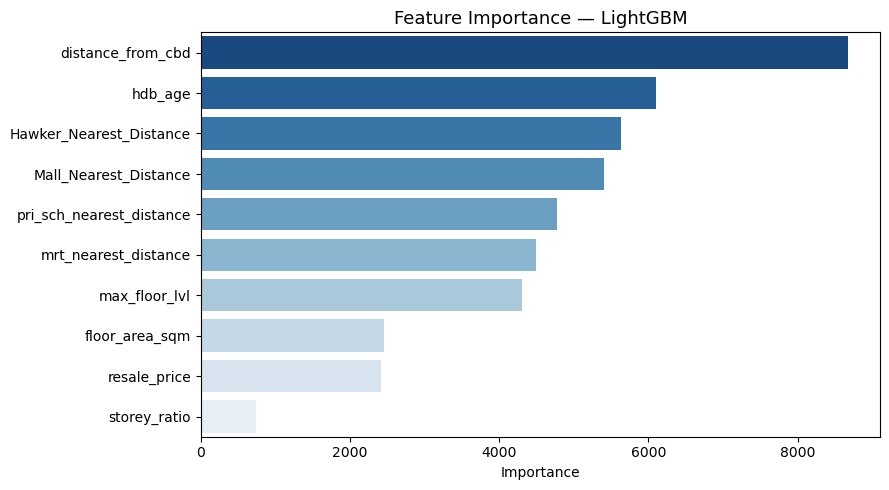


Feature importances (ranked):
                 Feature  Importance
       distance_from_cbd        8671
                 hdb_age        6108
 Hawker_Nearest_Distance        5626
   Mall_Nearest_Distance        5410
pri_sch_nearest_distance        4776
    mrt_nearest_distance        4497
           max_floor_lvl        4308
          floor_area_sqm        2452
            resale_price        2413
            storey_ratio         739


In [16]:
importance_df = recommended_result['Feature Importance']

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=importance_df,
    x='Importance', y='Feature',
    palette='Blues_r', ax=ax
)
ax.set_title(f'Feature Importance — {recommended_name}', fontsize=13)
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("\nFeature importances (ranked):")
print(importance_df.to_string(index=False))

---

## Step 10: Export Artifacts

Saves all files needed by `app/app.py` to serve recommendations.

| File | Purpose |
|---|---|
| `lgbm_classifier.joblib` | Trained classifier (predict cluster from buyer features) |
| `scaler_classifier.joblib` | StandardScaler — must be applied before prediction |
| `cluster_labels.json` | Cluster ID → descriptive name (e.g. "Mature Central") |
| `town_cluster_map.json` | Town → cluster ID (for returning towns within predicted cluster) |
| `classifier_feature_columns.json` | Feature order — `app.py` must build its array in this exact order |

In [ ]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../app/models")
MODEL_DIR.mkdir(exist_ok=True)

best_model = recommended_result['fitted_model']

# 1. Classifier — saved as lgbm_classifier.joblib regardless of which model won
#    (app.py loads this single filename)
joblib.dump(best_model, MODEL_DIR / "lgbm_classifier.joblib")
print(f"Saved: lgbm_classifier.joblib  (model type: {type(best_model).__name__})")

# 2. Scaler — must be applied at inference (model trained on scaled features)
joblib.dump(scaler, MODEL_DIR / "scaler_classifier.joblib")
print("Saved: scaler_classifier.joblib")

# 3. Cluster descriptions — displayed in the app recommendation output
cluster_descriptions = {str(k): v for k, v in CLUSTER_NAMES.items()}
with open(MODEL_DIR / "cluster_labels.json", "w") as f:
    json.dump(cluster_descriptions, f, indent=2)
print(f"Saved: cluster_labels.json  ({len(cluster_descriptions)} clusters)")

# 4. Town → cluster map — app uses this to return towns within the predicted cluster
town_cluster_map = {
    row['town']: int(row['cluster'])
    for _, row in town_profiles.iterrows()
}
with open(MODEL_DIR / "town_cluster_map.json", "w") as f:
    json.dump(town_cluster_map, f, indent=2)
print(f"Saved: town_cluster_map.json  ({len(town_cluster_map)} towns)")

# 5. Feature column order — app.py must build its input array in exactly this order
with open(MODEL_DIR / "classifier_feature_columns.json", "w") as f:
    json.dump(CLASSIFIER_FEATURES, f, indent=2)
print(f"Saved: classifier_feature_columns.json  ({len(CLASSIFIER_FEATURES)} features)")

# 6. Town profiles — per-town median of CLASSIFIER_FEATURES for inference-time similarity scoring
#    app.py scales these at startup using the saved scaler, then computes L2 distance
#    between each town's profile and the buyer's input vector to rank towns within a cluster
town_clf_profiles = df.groupby('town')[CLASSIFIER_FEATURES].median()
town_profiles_dict = town_clf_profiles.to_dict(orient='index')
with open(MODEL_DIR / "town_profiles.json", "w") as f:
    json.dump(town_profiles_dict, f, indent=2)
print(f"Saved: town_profiles.json  ({len(town_profiles_dict)} towns x {len(CLASSIFIER_FEATURES)} features)")

print("\nAll artifacts saved. Update and restart app/app.py to serve recommendations.")